In [10]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [11]:
df = pd.read_csv('data/container-ports-2000-2017.csv')

In [12]:
df.columns

Index(['U.S. Custom Ports', 'Coast', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   U.S. Custom Ports  63 non-null     object
 1   Coast              62 non-null     object
 2   2000               63 non-null     object
 3   2001               63 non-null     object
 4   2002               63 non-null     object
 5   2003               63 non-null     object
 6   2004               63 non-null     object
 7   2005               63 non-null     object
 8   2006               63 non-null     object
 9   2007               63 non-null     object
 10  2008               63 non-null     object
 11  2009               63 non-null     object
 12  2010               63 non-null     object
 13  2011               63 non-null     object
 14  2012               63 non-null     object
 15  2013               63 non-null     object
 16  2014               63 non-null     object
 17 

C:\Users\Isaac\AppData\Local\Temp\ipykernel_22736\2582879585.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_atlantic['2017'] = df_atlantic['2017'].replace(',', '', regex=True).astype(float)


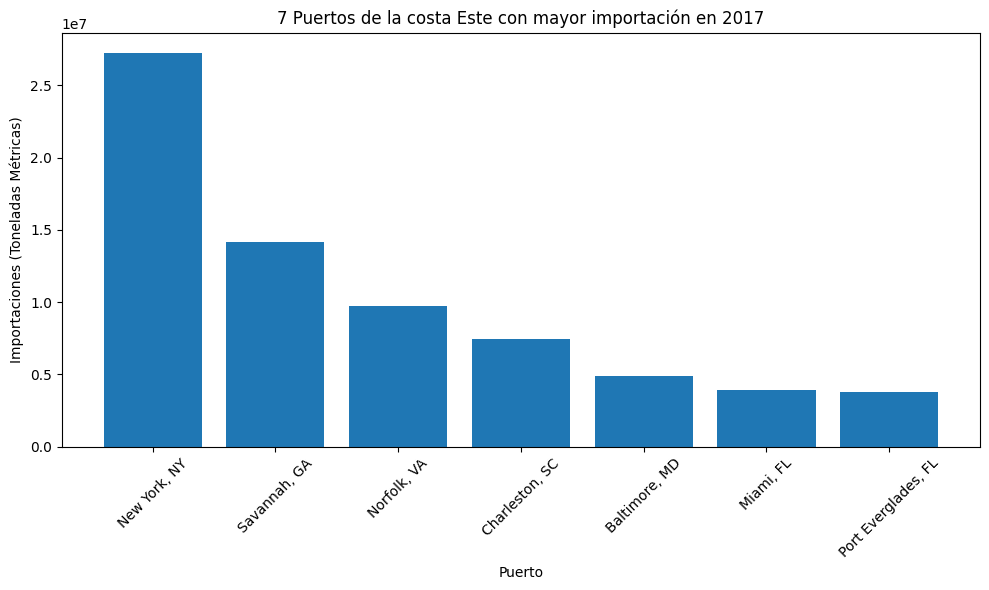

In [14]:
# Filtrar los datos para la costa 'A' (Costa Atlántica)
df_atlantic = df[df['Coast'] == 'A']

# Asegurarse de que la columna 2017 esté en formato numérico
df_atlantic['2017'] = df_atlantic['2017'].replace(',', '', regex=True).astype(float)

# Obtener los 5 puertos de la costa A con mayor peso en 2017
top_7_atlantic_2017 = df_atlantic.nlargest(7, '2017')

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(top_7_atlantic_2017['U.S. Custom Ports'], top_7_atlantic_2017['2017'])
plt.title('7 Puertos de la costa Este con mayor importación en 2017')
plt.xlabel('Puerto')
plt.ylabel('Importaciones (Toneladas Métricas)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:
top_7_atlantic_2017

,U.S. Custom Ports,Coast,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
33,"New York, NY",A,"12,601,998","12,757,871","14,994,218","15,659,527","17,919,332","19,327,786","20,796,490","20,962,153","20,482,101","18,117,942","20,756,851","21,601,624","22,244,864","22,322,601","23,645,442","25,214,798","25,748,459",27282529.0
55,"Savannah, GA",A,"2,912,963","2,997,957","3,751,126","3,983,050","4,549,810","5,428,134","6,005,987","7,423,123","7,517,652","6,343,155","7,488,311","7,665,392","7,798,747","8,319,048","9,607,638","11,147,416","12,306,893",14144622.0
35,"Norfolk, VA",A,"3,571,230","3,555,987","4,266,647","4,747,036","5,464,117","5,862,544","6,456,294","6,597,866","6,297,416","5,235,987","5,554,618","5,645,865","6,511,908","7,094,322","7,659,810","7,978,292","8,855,199",9717373.0
10,"Charleston, SC",A,"4,973,605","4,889,872","5,277,534","5,450,765","6,416,369","6,893,467","6,721,235","5,893,683","5,388,496","3,920,396","4,332,778","4,642,272","4,975,032","5,153,465","5,814,406","6,461,162","6,823,275",7445505.0
3,"Baltimore, MD",A,"1,899,689","1,942,158","2,189,129","2,077,996","2,641,888","2,640,988","2,824,549","2,756,330","2,855,096","2,380,630","2,929,029","3,108,746","3,243,542","3,438,606","3,691,480","3,977,777","4,264,068",4871362.0
30,"Miami, FL",A,"3,033,222","3,119,778","3,623,014","3,741,957","4,141,083","3,950,136","3,955,994","2,975,330","2,574,809","2,310,557","2,379,356","2,571,517","2,626,769","2,895,457","3,144,408","3,680,764","3,751,318",3881166.0
45,"Port Everglades, FL",A,"1,275,848","1,235,358","1,169,853","1,373,869","1,773,548","2,258,038","2,504,934","2,653,498","2,430,382","1,916,587","2,170,737","2,303,356","2,432,516","2,999,952","3,333,669","3,407,678","3,541,178",3744001.0


In [16]:
def muestraHistograma(puerto):
    # Convertir las columnas de años a formato numérico, eliminando comas si es necesario
    years = [str(year) for year in range(2000, 2018)]

    # Filtrar los datos del puerto
    ny_port = df[df['U.S. Custom Ports'] == puerto].copy()

    # Convertir las columnas de años a formato numérico
    ny_port[years] = ny_port[years].replace(',', '', regex=True).astype(float)

    # Extraer los datos de importación para los años 2000-2017
    ny_imports = ny_port[years].values.flatten()

    # Crear gráfico de línea para mostrar la evolución de importaciones en New York, NY
    plt.figure(figsize=(10, 6))
    plt.plot(years, ny_imports, marker='o', linestyle='-')
    plt.title('Evolución de Importaciones en '+ puerto +' (2000–2017)')
    plt.xlabel('Año')
    plt.ylabel('Importaciones (Toneladas Métricas)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()  

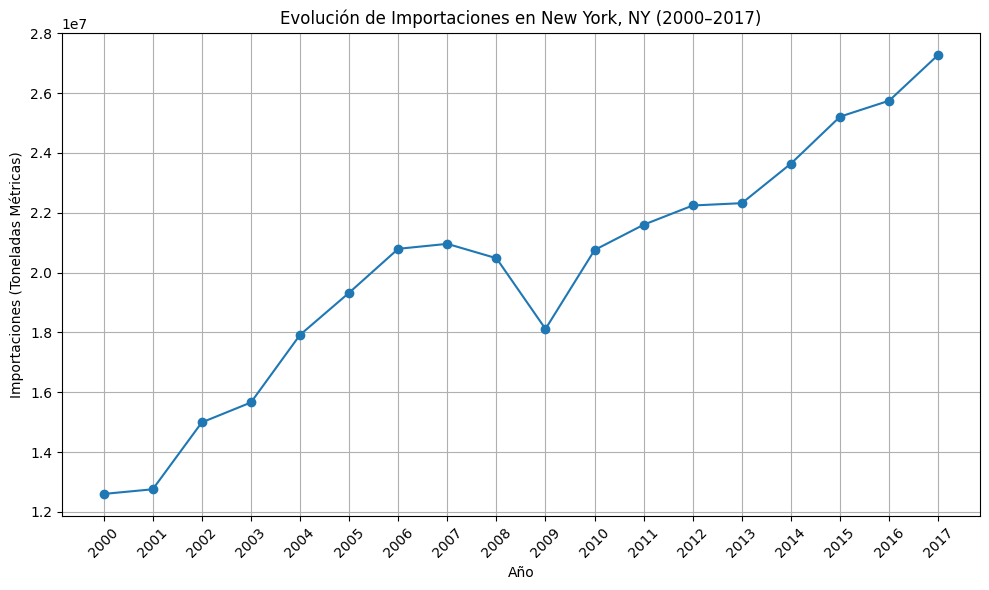

In [17]:
muestraHistograma('New York, NY')

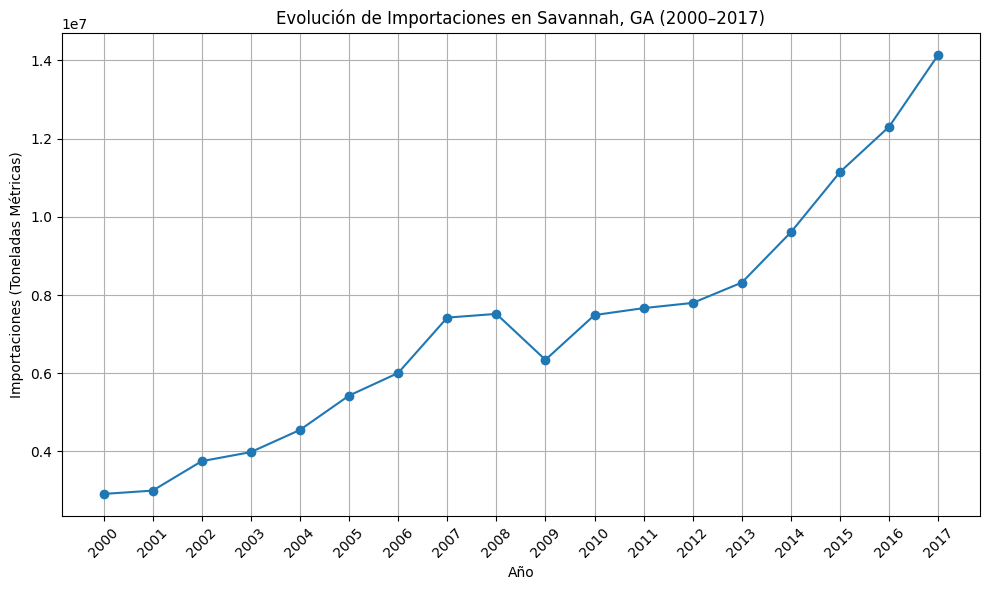

In [18]:
muestraHistograma('Savannah, GA')

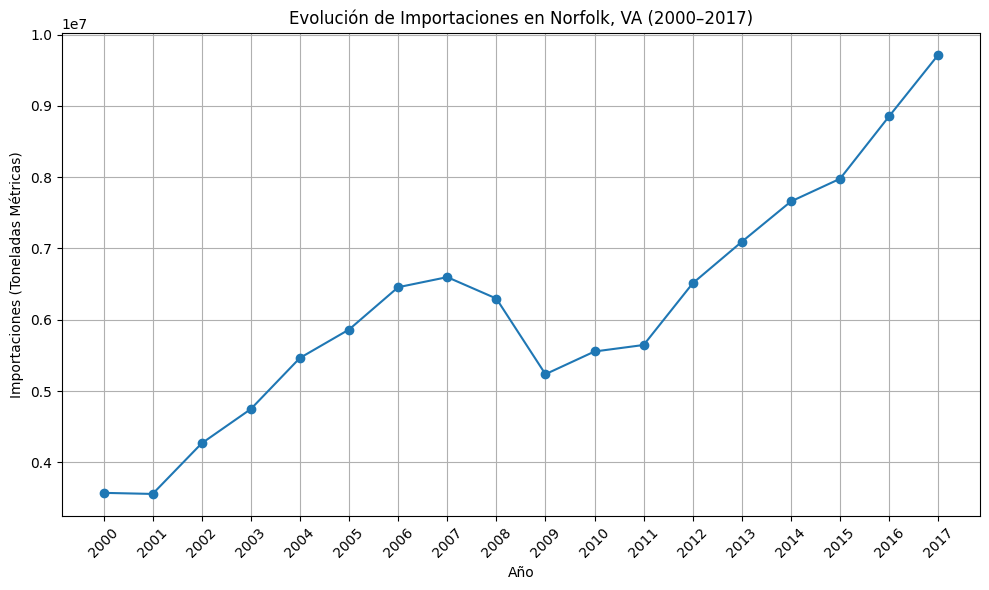

In [19]:
muestraHistograma('Norfolk, VA')

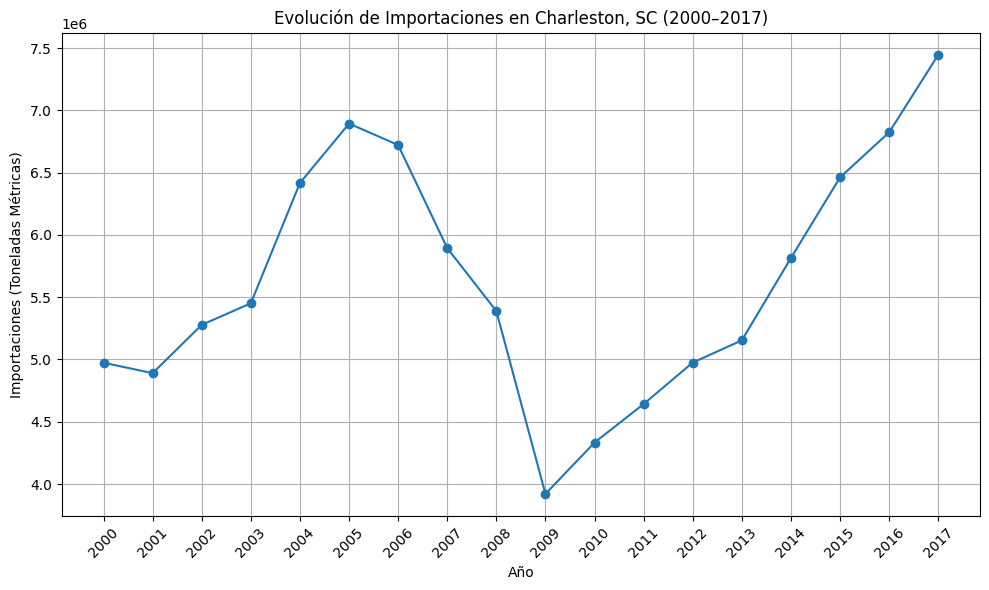

In [20]:
muestraHistograma('Charleston, SC')

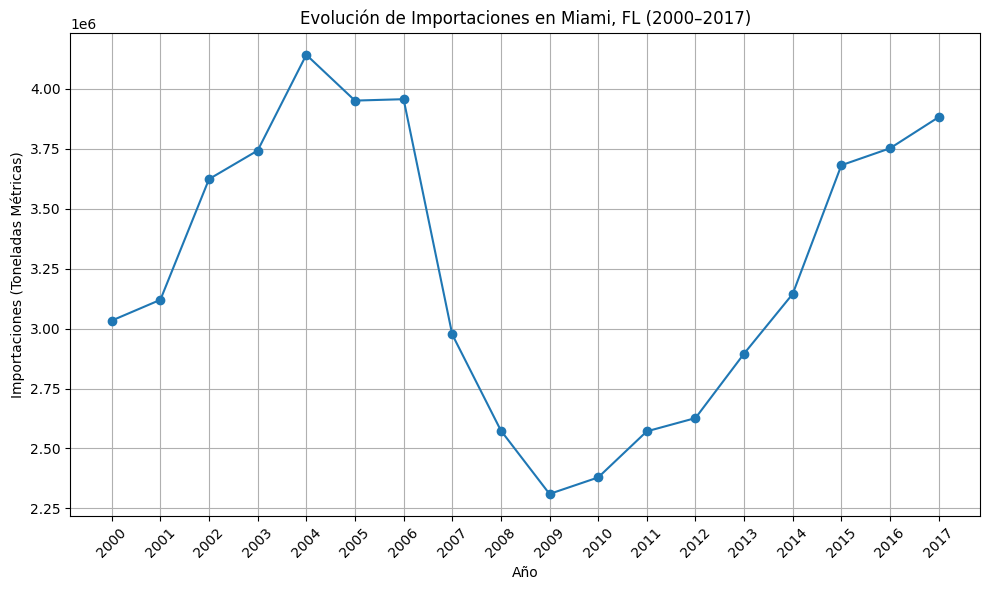

In [21]:
muestraHistograma('Miami, FL')

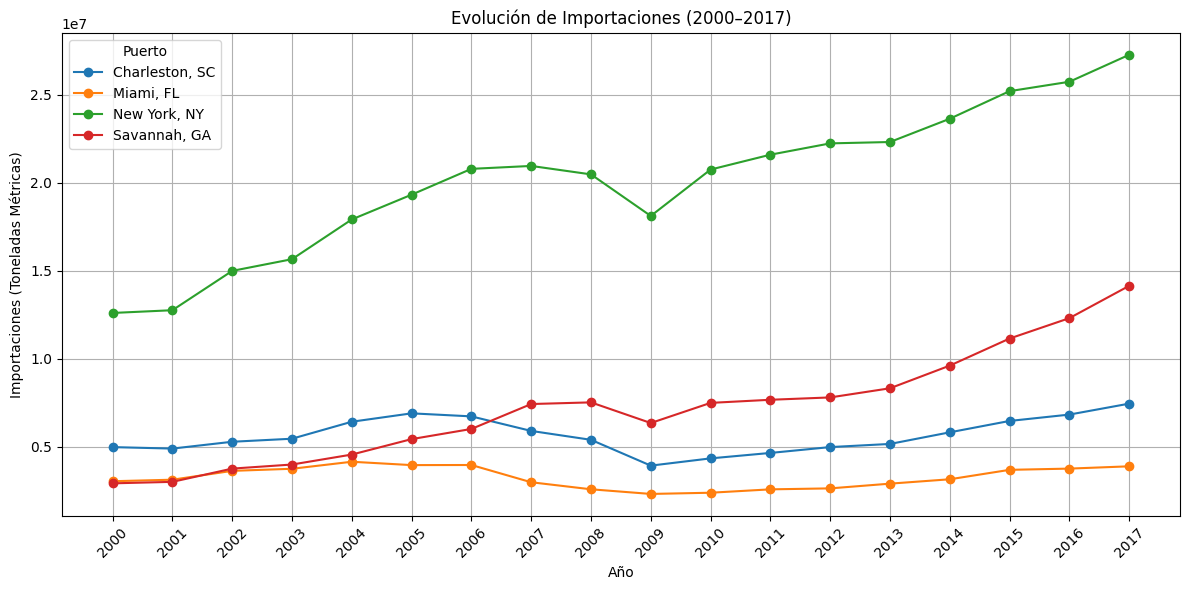

In [22]:
# Lista de años y puertos seleccionados
years = [str(year) for year in range(2000, 2018)]
selected_ports = ['New York, NY', 'Savannah, GA', 'Charleston, SC', 'Miami, FL']

# Filtrar el dataset para los puertos seleccionados
df_selected = df[df['U.S. Custom Ports'].isin(selected_ports)].copy()

# Asegurarse de que los datos estén en formato numérico
df_selected[years] = df_selected[years].replace(',', '', regex=True).astype(float)

# Crear gráfico de líneas múltiples
plt.figure(figsize=(12, 6))
for _, row in df_selected.iterrows():
    plt.plot(years, row[years], marker='o', label=row['U.S. Custom Ports'])

plt.title('Evolución de Importaciones (2000–2017)')
plt.xlabel('Año')
plt.ylabel('Importaciones (Toneladas Métricas)')
plt.xticks(rotation=45)
plt.legend(title='Puerto')
plt.grid(True)
plt.tight_layout()
plt.show()

El coeficiente de correlación de Pearson entre los puertos de Los Angeles, CA y New York, NY es aproximadamente 0.86, lo que indica una fuerte correlación positiva entre las importaciones en estos dos puertos entre los años 2000 y 2017.

In [23]:
# Cargar nuevamente los datos relevantes para el análisis de correlación
years = [str(year) for year in range(2000, 2018)]
df_la_ny = df[df['U.S. Custom Ports'].isin(['Los Angeles, CA', 'New York, NY'])].copy()
df_la_ny[years] = df_la_ny[years].replace(',', '', regex=True).astype(float)

# Transponer para tener los años como índice y puertos como columnas
df_la_ny_transposed = df_la_ny.set_index('U.S. Custom Ports')[years].T
df_la_ny_transposed.columns = ['Los Angeles, CA', 'New York, NY']

# Calcular correlación de Pearson
correlation = df_la_ny_transposed.corr().loc['Los Angeles, CA', 'New York, NY']

# Mostrar resultado
correlation

0.8615781544716864

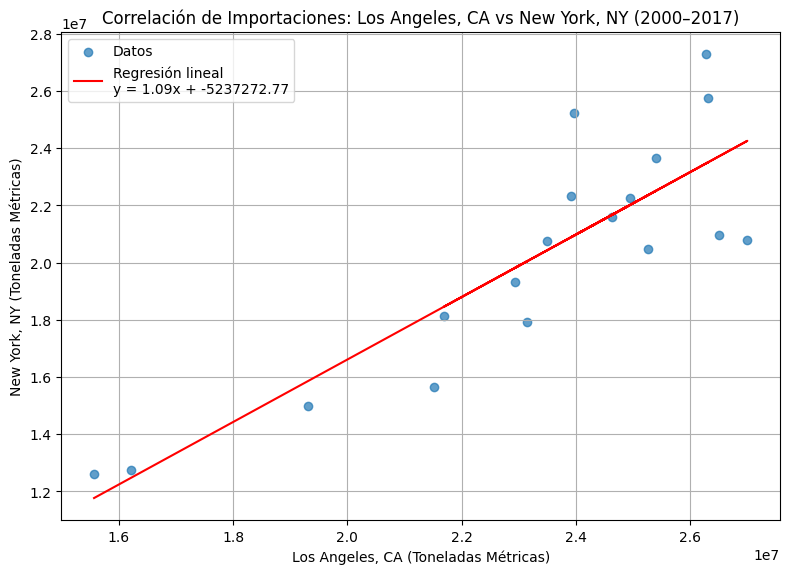

In [24]:
# Extraer los datos para ajustar la recta
x = df_la_ny_transposed['Los Angeles, CA']
y = df_la_ny_transposed['New York, NY']

# Ajustar una recta de regresión lineal (y = mx + b)
m, b = np.polyfit(x, y, 1)

# Crear gráfico con línea de regresión
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, label='Datos')
plt.plot(x, m * x + b, color='red', label=f'Regresión lineal\ny = {m:.2f}x + {b:.2f}')
plt.title('Correlación de Importaciones: Los Angeles, CA vs New York, NY (2000–2017)')
plt.xlabel('Los Angeles, CA (Toneladas Métricas)')
plt.ylabel('New York, NY (Toneladas Métricas)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

¿Qué significa esto?
Cuando aumentan las importaciones en Los Angeles, generalmente también aumentan en New York, y viceversa. Esto sugiere que ambos puertos responden a dinámicas similares del comercio internacional, probablemente influenciadas por factores macroeconómicos globales como el crecimiento económico de EE.UU., la demanda de bienes de consumo, y la relación comercial con Asia.

Correlación entre los puertos de MIAMI y New York. 0.08

In [25]:
# Filtrar datos de los puertos Miami, FL y New York, NY
df_miami_ny = df[df['U.S. Custom Ports'].isin(['Miami, FL', 'New York, NY'])].copy()
df_miami_ny[years] = df_miami_ny[years].replace(',', '', regex=True).astype(float)

# Transponer para tener los años como índice y puertos como columnas
df_miami_ny_transposed = df_miami_ny.set_index('U.S. Custom Ports')[years].T
df_miami_ny_transposed.columns = ['Miami, FL', 'New York, NY']

# Calcular correlación de Pearson
correlation_miami_ny = df_miami_ny_transposed.corr().loc['Miami, FL', 'New York, NY']
correlation_miami_ny

0.07745308228219203

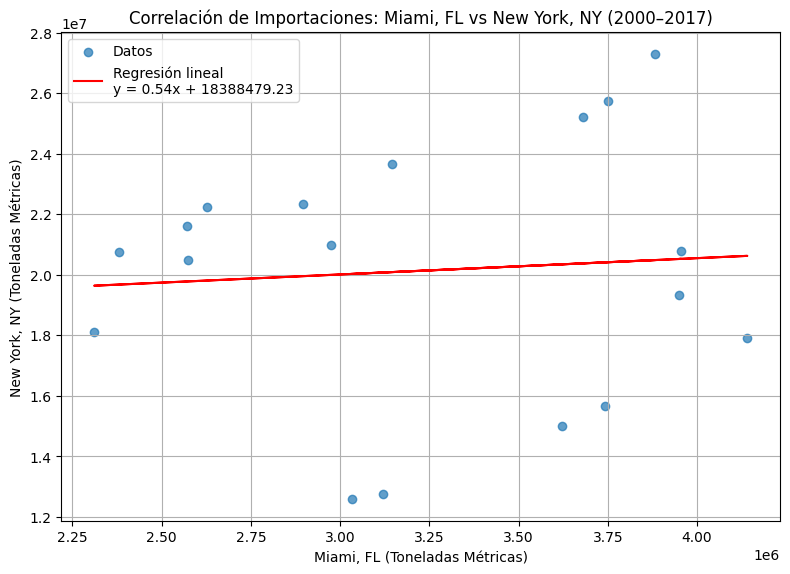

In [26]:
# Extraer los datos para ajustar la recta
x_miami = df_miami_ny_transposed['Miami, FL']
y_ny = df_miami_ny_transposed['New York, NY']

# Ajustar una recta de regresión lineal (y = mx + b)
m_miami_ny, b_miami_ny = np.polyfit(x_miami, y_ny, 1)

# Crear gráfico con línea de regresión
plt.figure(figsize=(8, 6))
plt.scatter(x_miami, y_ny, alpha=0.7, label='Datos')
plt.plot(x_miami, m_miami_ny * x_miami + b_miami_ny, color='red', label=f'Regresión lineal\ny = {m_miami_ny:.2f}x + {b_miami_ny:.2f}')
plt.title('Correlación de Importaciones: Miami, FL vs New York, NY (2000–2017)')
plt.xlabel('Miami, FL (Toneladas Métricas)')
plt.ylabel('New York, NY (Toneladas Métricas)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

No hay una relación lineal significativa entre las importaciones en Miami y New York en el período 2000–2017. Es decir, los aumentos o disminuciones en las importaciones de un puerto no están relacionados directamente con los del otro. Esto puede deberse a que ambos puertos manejan diferentes tipos de carga, mercados de destino, o están influenciados por factores logísticos y comerciales distintos.

Modelo ANOVA de 'New York, NY', 'Savannah, GA', 'Charleston, SC'

In [27]:
# Lista de puertos a comparar
puertos = ['New York, NY', 'Savannah, GA', 'Charleston, SC']
years = [str(year) for year in range(2000, 2018)]

# Filtrar y preparar los datos
df_filtrado = df[df['U.S. Custom Ports'].isin(puertos)].copy()
df_filtrado[years] = df_filtrado[years].replace(',', '', regex=True).astype(float)

# Obtener las importaciones por puerto
importaciones = [df_filtrado[df_filtrado['U.S. Custom Ports'] == puerto][years].values.flatten()
                for puerto in puertos]

# Ejecutar ANOVA
resultado_anova = f_oneway(*importaciones)

# Mostrar resultados
print("F =", resultado_anova.statistic)
print("p =", resultado_anova.pvalue)

F = 119.77424936211034
p = 5.382255107158895e-20


Modelo ANOVA de 'New York, NY', 'Savannah, GA', 'Charleston, SC'

In [28]:

# Lista de puertos a comparar
puertos = ['New York, NY', 'Los Angeles, CA']
years = [str(year) for year in range(2000, 2018)]

# Filtrar y preparar los datos
df_filtrado = df[df['U.S. Custom Ports'].isin(puertos)].copy()
df_filtrado[years] = df_filtrado[years].replace(',', '', regex=True).astype(float)

# Obtener las importaciones por puerto
importaciones = [df_filtrado[df_filtrado['U.S. Custom Ports'] == puerto][years].values.flatten()
                for puerto in puertos]

# Ejecutar ANOVA
resultado_anova = f_oneway(*importaciones)

# Mostrar resultados
print("F =", resultado_anova.statistic)
print("p =", resultado_anova.pvalue)

F = 5.999040479961847
p = 0.019621204904823927


En ambos casos como p < 0.05 rechazamos la hipótesis nula de que los puertos tienen la misma media de importaciones. En otras palabras, hay evidencia estadísticamente significativa de que las importaciones entre New York y Los Angeles son diferentes

Series de Tiempo. Se realiza análisis de serie de tiempo con el modelo Holt-Winter 

c:\Users\Isaac\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


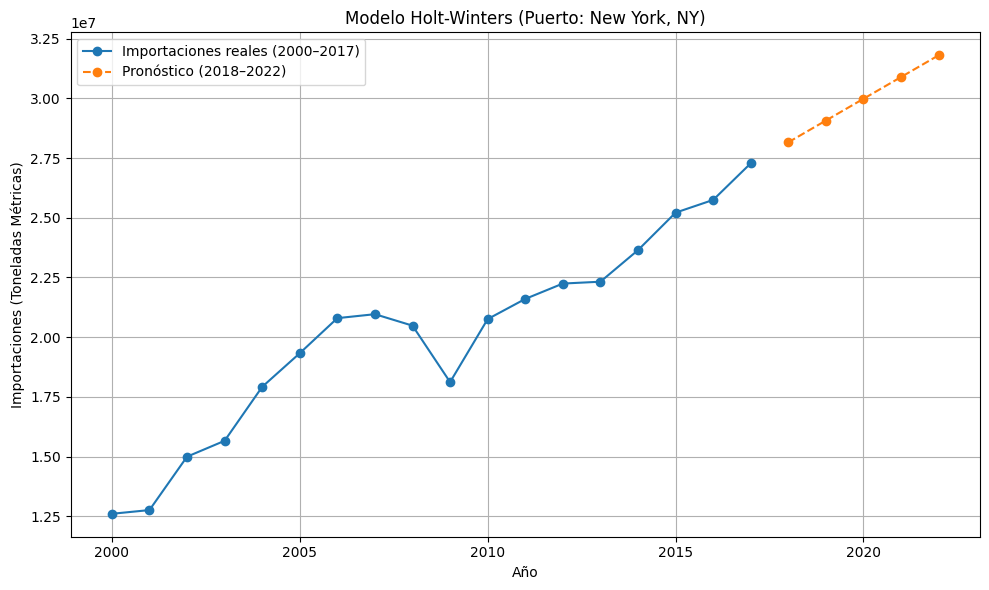

In [29]:
# Lista de años
years = [str(year) for year in range(2000, 2018)]

# Filtrar datos del puerto 'New York, NY' y convertir a numérico
df_ny = df[df['U.S. Custom Ports'] == 'New York, NY'].copy()
df_ny[years] = df_ny[years].replace(',', '', regex=True).astype(float)

# Crear serie de tiempo
ts_ny = pd.Series(df_ny[years].values.flatten(), index=pd.Index(range(2000, 2018), name='Año'))

# Aplicar modelo Holt-Winters (tendencia aditiva, sin estacionalidad)
model = ExponentialSmoothing(ts_ny, trend='add', seasonal=None, seasonal_periods=None)
fit_model = model.fit()

# Generar predicción para los próximos 5 años
forecast_years = list(range(2018, 2023))
forecast = fit_model.forecast(len(forecast_years))

# Graficar resultados
plt.figure(figsize=(10, 6))
plt.plot(ts_ny, label='Importaciones reales (2000–2017)', marker='o')
plt.plot(forecast, label='Pronóstico (2018–2022)', linestyle='--', marker='o')
plt.title('Modelo Holt-Winters (Puerto: New York, NY)')
plt.xlabel('Año')
plt.ylabel('Importaciones (Toneladas Métricas)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

La línea sólida representa los datos reales de importaciones desde el año 2000 hasta 2017. La línea punteada muestra el pronóstico de importaciones para 2018–2022.
Es importante destacar que en este caso el análisis se hizo sin estacionalidad ya que no observé una estacionalidad clara de manera visual en la serie de tiempo.


Análisis de regresión con tendencia exponencial.

In [30]:
# Preparar años y puerto
years = [str(year) for year in range(2000, 2018)]
df_ny = df[df['U.S. Custom Ports'] == 'New York, NY'].copy()
df_ny[years] = df_ny[years].replace(',', '', regex=True).astype(float)

# Crear serie de tiempo
ts_ny = pd.Series(df_ny[years].values.flatten(), index=pd.Index(range(2000, 2018), name='Año'))

# Preparar datos para regresión exponencial
X = np.array(range(2000, 2018)).reshape(-1, 1)
y = ts_ny.values
log_y = np.log(y)

# Ajustar modelo lineal sobre log(y)
reg = LinearRegression().fit(X, log_y)
log_y_pred = reg.predict(X)
y_pred = np.exp(log_y_pred)

# Calcular R^2
r2 = r2_score(y, y_pred)

# Coeficientes del modelo exponencial: y = a * e^(b*x)
a = np.exp(reg.intercept_)
b = reg.coef_[0]



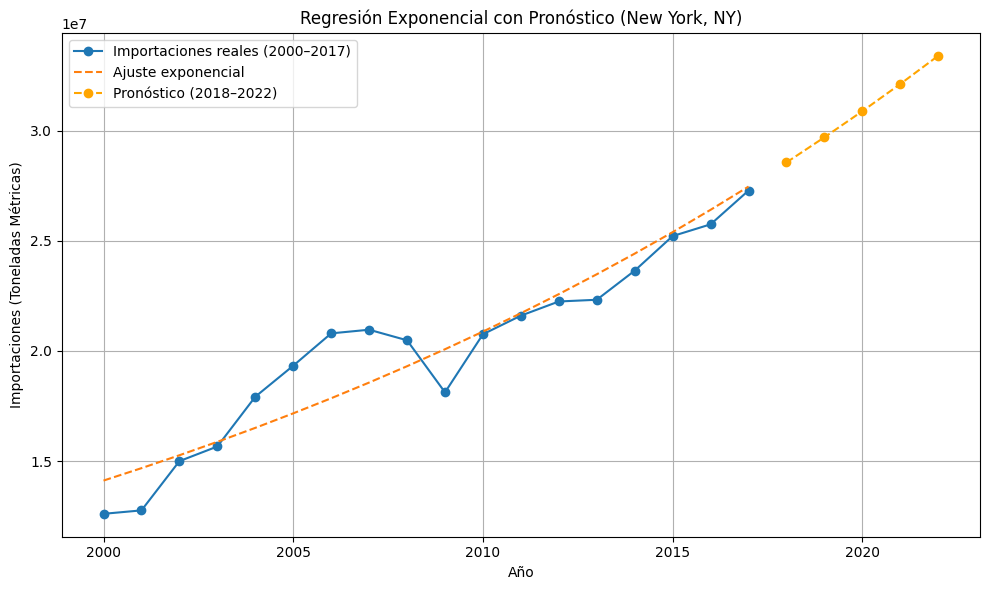

{2018: 28560321.221615538,
 2019: 29701150.290912278,
 2020: 30887549.25962439,
 2021: 32121338.396703333,
 2022: 33404410.68091638}

In [31]:
# Años futuros
future_years = np.array(range(2018, 2023)).reshape(-1, 1)

# Calcular predicciones con el modelo exponencial ajustado
future_log_y_pred = reg.predict(future_years)
future_y_pred = np.exp(future_log_y_pred)

# Graficar datos reales, ajuste y predicciones
plt.figure(figsize=(10, 6))
plt.plot(X.flatten(), y, label='Importaciones reales (2000–2017)', marker='o')
plt.plot(X.flatten(), y_pred, label='Ajuste exponencial', linestyle='--')
plt.plot(future_years.flatten(), future_y_pred, label='Pronóstico (2018–2022)', linestyle='--', marker='o', color='orange')
plt.title('Regresión Exponencial con Pronóstico (New York, NY)')
plt.xlabel('Año')
plt.ylabel('Importaciones (Toneladas Métricas)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostrar predicciones numéricas
dict(zip(future_years.flatten(), future_y_pred))